In [ ]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=1
import numpy as np

import sys
from utils.utils import get_path

import os
from scipy import sparse
from vis_utils.loaders import load_dataset
import matplotlib.pyplot as plt
from vis_utils.plot import plot_scatter
from vis_utils.utils import load_dict, save_dict
from openTSNE.affinity import Affinities
from vis_utils.tsne_wrapper import TSNEwrapper
from ripser import Rips
from mpl_toolkits.axes_grid1 import make_axes_locatable
import tadasets
from ripser import ripser
from persim import plot_diagrams
from matplotlib import collections  as mc

from matplotlib.colors import Normalize
import torch
import pandas as pd
# cannot find this....but its not really necessary....
# from utils import parse_lines_0, parse_lines_1, get_cocycle_id, cohom_decoding


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: CUDA_VISIBLE_DEVICES=1


<h4 style="background-color: yellow; padding: 5px;">

tsne embedding for yao 10x. Mostly just to eye ball if there are any holes in the 2d embedding, which could indicate potential holes in higher dimensions. 

</h4>

# both sex

In [721]:
dataset = "yao_10x"
root_path = get_path("data")

In [722]:
x, y, sknn, pca2, d = load_dataset(root_path, dataset)
k = 15
n_epochs = 500
n_early_epochs = 250
perplexity = None
rescale_tsne = True
seed = 0

if rescale_tsne:
    pca_tsne = pca2 / np.std(pca2[:, 0]) / 10000
else:
    pca_tsne = pca2
affinities = Affinities()
affinities.P = (sknn / sknn.sum()).tocsr()

file_name = os.path.join(root_path,
                         dataset,
                         f"tsne_bin_k_{k}_n_epochs_{n_epochs}_n_early_epochs_{n_early_epochs}_seed_{seed}_init_pca_rescale_{rescale_tsne}.pkl")
try:
    tsne_data = load_dict(file_name)
    embd = tsne_data["embds"][-1]
except FileNotFoundError:
    tsne = TSNEwrapper(perplexity=perplexity,
                metric="euclidean",
                n_jobs=5, # n_jobs=-10 does not work well, the cell does not print anything
                random_state=seed,
                verbose=True,
                n_iter = n_epochs,
                early_exaggeration_iter = n_early_epochs,
                callbacks_every_iters=1,
                log_kl=False,
                log_embds=True,
                log_Z=False
                )

    embd = tsne.fit_transform(X=x,
                              affinities=affinities,
                              initialization=pca_tsne
                              )
    save_dict(tsne.aux_data, file_name)




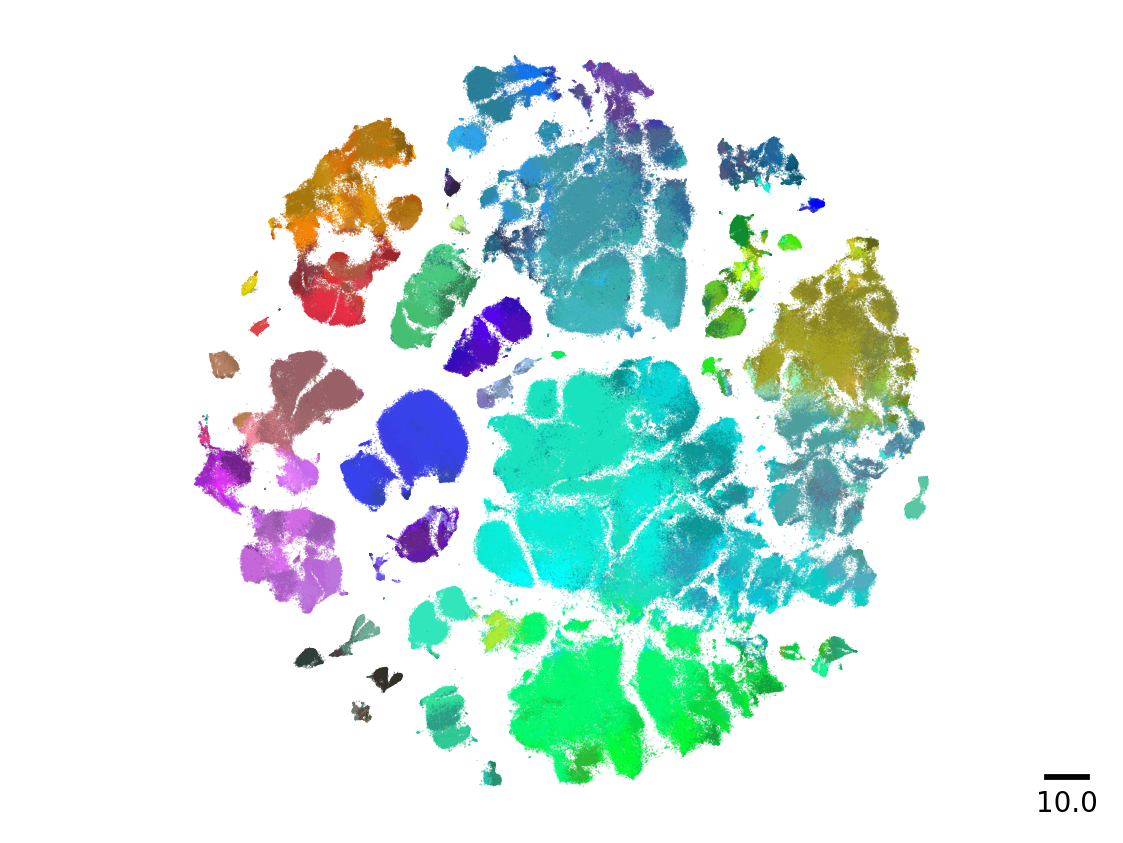

In [ ]:

fig, ax = plt.subplots()
plot_scatter(ax, embd, d["clusterColors"][y])
fig.savefig(os.path.join(get_path("figures"), f"tsne_embe_yao_10x.png"), dpi=300)


# female

In [34]:
dataset = "yao_10x_female"
root_path = get_path("data")

In [37]:
x, y, sknn, pca2, d = load_dataset(root_path, dataset)
k = 15
n_epochs = 500
n_early_epochs = 250
perplexity = None
rescale_tsne = True
seed = 0

if rescale_tsne:
    pca_tsne = pca2 / np.std(pca2[:, 0]) / 10000
else:
    pca_tsne = pca2
affinities = Affinities()
affinities.P = (sknn / sknn.sum()).tocsr()

file_name = os.path.join(root_path,
                         dataset,
                         f"tsne_bin_k_{k}_n_epochs_{n_epochs}_n_early_epochs_{n_early_epochs}_seed_{seed}_init_pca_rescale_{rescale_tsne}.pkl")
try:
    tsne_data = load_dict(file_name)
    embd_female = tsne_data["embds"][-1]
except FileNotFoundError:
    tsne = TSNEwrapper(perplexity=perplexity,
                metric="euclidean",
                n_jobs=5, # n_jobs=-10 does not work well, the cell does not print anything
                random_state=seed,
                verbose=True,
                n_iter = n_epochs,
                early_exaggeration_iter = n_early_epochs,
                callbacks_every_iters=1,
                log_kl=False,
                log_embds=True,
                log_Z=False
                )

    embd_female = tsne.fit_transform(X=x,
                              affinities=affinities,
                              initialization=pca_tsne
                              )
    save_dict(tsne.aux_data, file_name)




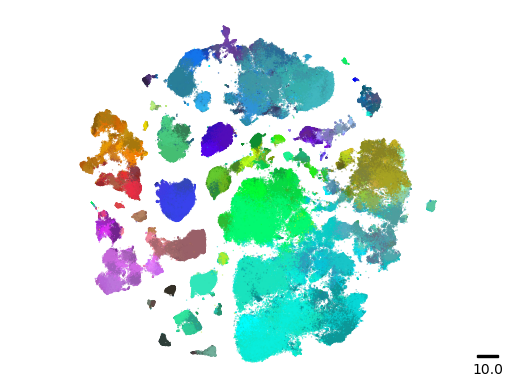

In [ ]:

fig, ax = plt.subplots()
plot_scatter(ax, embd_female, d["clusterColors"][y])
fig.savefig(os.path.join(get_path("figures"), f"tsne_embe_yao_10x_female.png"), dpi=300)
